In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 4: 연령대를 10세 단위로 나누고, 각 연령대별로 가장 선호하는 상품 카테고리를 찾으세요.
# 시각화: 누적 바 차트

# 비즈니스 목적: 연령대별로 선호하는 상품군이 다르다는 가설을 검증하고, 연령 타겟 마케팅 및 상품 소싱 전략에 활용합니다.

###### 출력 결과를 보고 코딩하세요
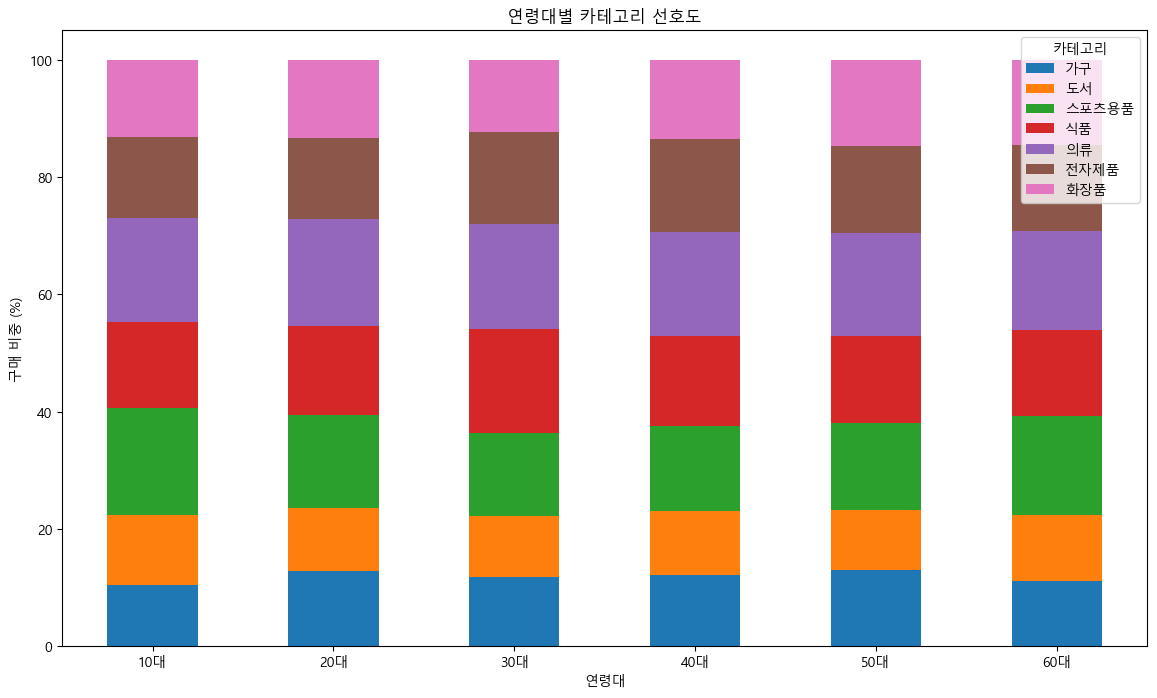

```
연령대별 최고 선호 카테고리:
age_group
10대    스포츠용품
20대       의류
30대       의류
40대       의류
50대       의류
60대       의류
dtype: objectz
```

In [3]:
print(df['payment_status'].unique())
print(df['payment_status'].value_counts())

['Completed' 'Failed' 'Pending']
payment_status
Completed    9043
Pending       483
Failed        474
Name: count, dtype: int64


In [8]:
# 필요한 데이터 - 결제/구매상태는 제외하고 나이, 카테고리 + 총구매액 
df.columns
cols = ['age','category', 'total_sales', 'quantity']
# filter_ = df['payment_status'] == 'Completed'
df_quest24 = df[cols].copy()

# 나이 xx대로 분류하기, 60대 이상은 60대로~
df_quest24['age_group'] = ((df_quest24['age'] // 10) * 10).clip(upper=60).astype(str) + '대'
# df_quest24['age_group'].value_counts()

# 각 연령대별 가장 선호하는 카테고리 찾기 - total_sales가 아닌 quantity로 
df_result = (df_quest24.groupby(['age_group', 'category'])['quantity'] # 연령대와 카테고리로 그룹핑 하고
            .sum() #  size()를 이용해서 카운트하고
            .reset_index(name='sales_sum') # size() 한 값을 count 컬럼으로 만들어 dataframe 생성
            .assign(sales_ratio=lambda x: x.groupby('age_group')['sales_sum'].transform(lambda y: y / y.sum() * 100))
            .sort_values(['age_group', 'sales_ratio'], ascending=[True, False]) # 연령대와 카운트한 값으로 정렬
)

# 각 연령대별 최고 선호 카테고리 추출 (카테고리명만)
# top_cateories = df_result.loc[df_result.groupby('age_group')['count'].idxmax()].set_index('age_group')['category']
top_cateories = df_result.groupby('age_group').first().reset_index().set_index('age_group')['category']
print("연령대별 최고 선호 카테고리:")
print(top_cateories) 


연령대별 최고 선호 카테고리:
age_group
10대    스포츠용품
20대       의류
30대       의류
40대       의류
50대       의류
60대       의류
Name: category, dtype: object


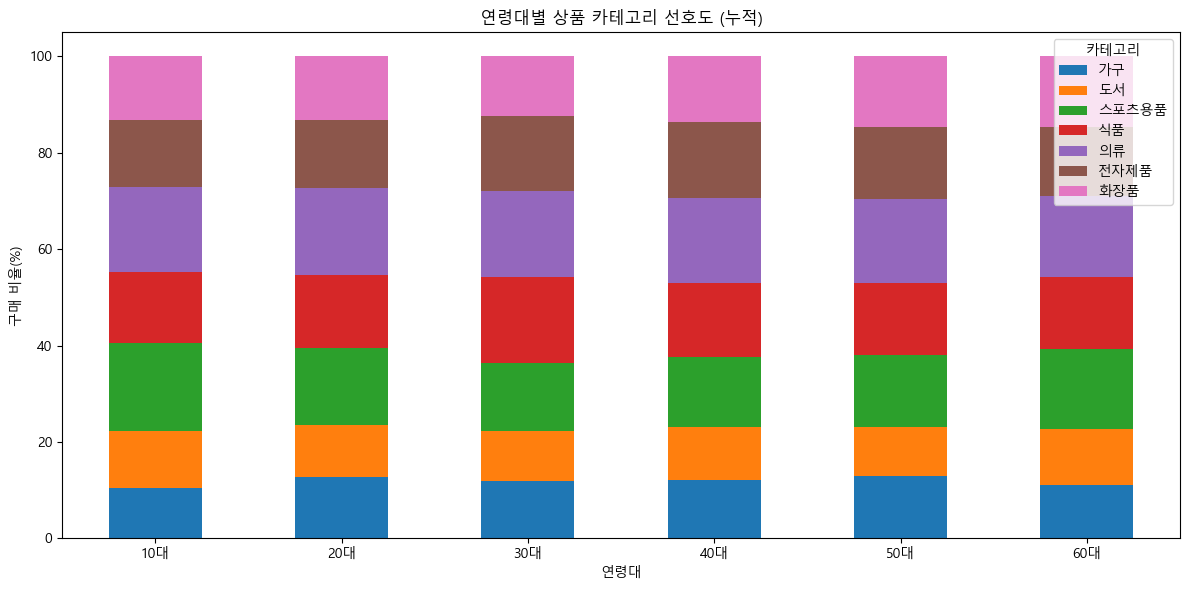

In [12]:
# ========== 누적 바 차트 시각화 ==========
# 피벗 테이블 생성 (연령대를 행, 카테고리를 열로)
pivot_data = df_result.pivot_table(
    index='age_group', 
    columns='category', 
    values='sales_ratio', 
    fill_value=0
)

# 누적 바 차트 그리기
fig, ax = plt.subplots(figsize=(12, 6))
pivot_data.plot(kind='bar', stacked=True, ax=ax) #, colormap='Set1'

# 차트 꾸미기
ax.set_title('연령대별 상품 카테고리 선호도 (누적)')
ax.set_xlabel('연령대')
ax.set_ylabel('구매 비율(%)')
ax.legend(title='카테고리', loc='upper right')
# ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()